# Analyse et modélisation des données e-commerce

Ce notebook examine les cinq exports bruts, documente les anomalies, nettoie et rassemble les données à la granularité d'une ligne de produit commandé, explore l'activité puis construit un modèle dimensionnel. Chaque décision est explicitée afin de distinguer les chiffres fiables des chiffres à confirmer.

Cette cellule importe les outils utilisés et fixe le dossier des fichiers ; cela rend le notebook reproductible depuis le dossier du rendu.

In [1]:
from pathlib import Path
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_DIR = Path('fichiers_evaluation')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 30)

Cette cellule charge les cinq fichiers sans modifier les valeurs : cette photographie initiale sert de référence avant nettoyage.

In [2]:
files = {
    'clients': 'clients.csv',
    'produits': 'produits.csv',
    'commandes': 'commandes.csv',
    'paiements': 'paiements.csv',
    'avis': 'avis_clients.csv'
}
raw = {name: pd.read_csv(DATA_DIR / filename) for name, filename in files.items()}
for name, df in raw.items():
    print(f'{name}: {df.shape[0]} lignes, {df.shape[1]} colonnes')
    display(df.head(3))

clients: 207 lignes, 8 colonnes


,id_client,nom,prenom,email,telephone,ville,region,date_inscription
0,CLI0001,Rabe,Tantely,tantely.rabe1@mail.mg,0326 812 251,Antsirabe,Vakinankaratra,2024-11-25
1,CLI0002,Andrianina,Mendrika,mendrika.andrianina2@mail.mg,+261 34 67 579 19,Fianarantsoa,Haute Matsiatra,2024-09-08
2,CLI0003,Rasoa,Miora,miora.rasoa3@mail.mg,0322110528,Toliara,Atsimo-Andrefana,2024-05-11


produits: 59 lignes, 5 colonnes


,id_produit,nom_produit,categorie,prix_unitaire,stock_disponible
0,PRD001,Smartphone,Electronique,559100.0,27
1,PRD002,Ecouteurs sans fil,Electronique,796800.0,112
2,PRD003,Chargeur rapide,Electronique,169200.0,196


commandes: 1223 lignes, 9 colonnes


,id_commande,id_client,id_produit,quantite,prix_unitaire,montant_ligne,date_commande,date_livraison,statut
0,CMD00254,CLI0179,PRD050,1,75400.0,75400.0,2025-04-20 08:13:00,2025-04-24,LIVRE
1,CMD00074,CLI0102,PRD036,1,157800.0,157800.0,22/03/2025 11:38,2025-03-27,LIVRE
2,CMD00046,CLI0121,PRD058,2,276600.0,553200.0,3 aout 2025 12:40,2025-08-13,LIVRE


paiements: 719 lignes, 6 colonnes


,id_paiement,id_commande,montant_paye,mode_paiement,date_paiement,statut_paiement
0,PAY00460,CMD00460,1079000.0,Especes a la livraison,2026-01-14 14:46:00,Valide
1,PAY00286,CMD00286,74000.0,Virement,2025-12-07 18:36:00,Valide
2,PAY00687,CMD00687,141800.0,Especes a la livraison,2025-12-06 11:00:00,Valide


avis: 406 lignes, 5 colonnes


,id_avis,id_commande,note,commentaire,date_avis
0,AVI00137,CMD00251,4.0,Bon produit,2025-12-07
1,AVI00100,CMD00359,4.0,Bien mais emballage moyen,2025-08-29
2,AVI00224,CMD00699,2.0,Emballage abime,2025-04-09


Cette cellule repère les valeurs absentes et les doublons ; ils peuvent empêcher les jointures ou biaiser les agrégations.

In [3]:
quality = []
for name, df in raw.items():
    quality.append({
        'fichier': name,
        'lignes': len(df),
        'doublons_lignes': int(df.duplicated().sum()),
        'cellules_nulles': int(df.isna().sum().sum())
    })
display(pd.DataFrame(quality))

clients, produits = raw['clients'].copy(), raw['produits'].copy()
commandes, paiements, avis = (raw[x].copy() for x in ['commandes', 'paiements', 'avis'])
print('Doublons id_commande:', commandes.id_commande.duplicated().sum())
print('Clients référencés mais absents:', sorted(set(commandes.id_client) - set(clients.id_client)))
print('Produits référencés mais absents:', sorted(set(commandes.id_produit) - set(produits.id_produit)))
print('Paiements orphelins:', len(set(paiements.id_commande) - set(commandes.id_commande)))
print('Avis orphelins:', len(set(avis.id_commande) - set(commandes.id_commande)))
print('Prix produits manquants:', produits.loc[produits.prix_unitaire.isna(), 'id_produit'].tolist())
print('Notes hors intervalle 1-5 ou manquantes:', int((~avis.note.between(1, 5)).sum() + avis.note.isna().sum()))
print('Montants de ligne incohérents:', int((commandes.montant_ligne.round(2) != (commandes.quantite * commandes.prix_unitaire).round(2)).sum()))
print('Paiements négatifs:', int((paiements.montant_paye < 0).sum()))

,fichier,lignes,doublons_lignes,cellules_nulles
0,clients,207,0,0
1,produits,59,0,5
2,commandes,1223,0,492
3,paiements,719,0,0
4,avis,406,6,9


Doublons id_commande: 514
Clients référencés mais absents: ['CLI9001', 'CLI9002', 'CLI9003', 'CLI9004', 'CLI9005', 'CLI9006', 'CLI9007', 'CLI9008', 'CLI9009', 'CLI9010', 'CLI9011', 'CLI9012', 'CLI9013', 'CLI9014']
Produits référencés mais absents: []
Paiements orphelins: 10
Avis orphelins: 0
Prix produits manquants: ['PRD014', 'PRD019', 'PRD038', 'PRD048', 'PRD057']
Notes hors intervalle 1-5 ou manquantes: 28
Montants de ligne incohérents: 50
Paiements négatifs: 8


Les catégories, villes, noms et statuts contiennent des différences de casse et d'espaces. Je les normalise pour éviter de créer artificiellement plusieurs modalités, sans changer le sens métier.

In [27]:
def clean_text(value):
    if pd.isna(value):
        return value
    return re.sub(r'\s+', ' ', str(value).strip())

def key_text(value):
    value = clean_text(value)
    if pd.isna(value):
        return value
    return ''.join(c for c in unicodedata.normalize('NFKD', value.lower()) if not unicodedata.combining(c))

for df in [clients, produits, commandes, paiements, avis]:
    for col in df.select_dtypes(include='str').columns:
        df[col] = df[col].map(clean_text)
clients['ville'] = clients['ville'].map(key_text).str.title()
clients['nom'] = clients['nom'].str.title()
clients['prenom'] = clients['prenom'].str.title()
produits['categorie'] = produits['categorie'].map(key_text).str.title()
commandes['statut'] = commandes['statut'].map(key_text).replace({'livre': 'LIVRE', 'expedie': 'EXPEDIE', 'en traitement': 'EN TRAITEMENT', 'annule': 'ANNULE'})
paiements['statut_paiement'] = paiements['statut_paiement'].map(key_text).str.upper()
display(commandes['statut'].value_counts())

statut
LIVRE            727
ANNULE           179
EN TRAITEMENT    158
EXPEDIE          151
Name: count, dtype: int64

Les dates mélangent ISO, formats avec slash et mois français. Je convertis les mois français connus puis j'utilise le parseur pandas ; les dates impossibles deviennent manquantes et sont comptées.

In [28]:
months = {'janvier':'January','fevrier':'February','février':'February','mars':'March','avril':'April','mai':'May','juin':'June','juillet':'July','aout':'August','août':'August','septembre':'September','octobre':'October','novembre':'November','decembre':'December','décembre':'December'}
def parse_mixed_date(value):
    if pd.isna(value): return pd.NaT
    text = key_text(value)
    for fr, en in months.items(): text = re.sub(fr, en, text, flags=re.I)
    iso_date = bool(re.match(r'^\d{4}-\d{2}-\d{2}', text))
    return pd.to_datetime(text, dayfirst=not iso_date, errors='coerce')

for df, cols in [(clients, ['date_inscription']), (commandes, ['date_commande','date_livraison']), (paiements, ['date_paiement']), (avis, ['date_avis'])]:
    for col in cols: df[col] = df[col].map(parse_mixed_date)
print('Dates de commande non interprétées:', commandes.date_commande.isna().sum())
print('Dates de livraison non renseignées:', commandes.date_livraison.isna().sum())

Dates de commande non interprétées: 0
Dates de livraison non renseignées: 488


Les clients ajoutés en doublon peuvent être reconnus par l'e-mail déjà présent. Je conserve le premier identifiant canonique et remappe les commandes, car l'e-mail est plus discriminant que le nom seul. Les commandes et avis orphelins sont exclus de la table croisée mais signalés.

In [6]:
clients['email_key'] = clients.email.str.lower().str.strip()
client_map = clients.drop_duplicates('email_key', keep='first').set_index('email_key').id_client.to_dict()
duplicate_client_rows = clients.duplicated('email_key').sum()
clients = clients.drop_duplicates('email_key', keep='first').copy()
email_to_id = dict(zip(clients.email_key, clients.id_client))
duplicate_ids = raw['clients'].set_index('id_client').email.str.lower().str.strip().map(email_to_id).dropna()
commandes['id_client_canonique'] = commandes.id_client.map(dict(zip(raw['clients'].id_client, duplicate_ids.reindex(raw['clients'].id_client).values)))
commandes['id_client_canonique'] = commandes['id_client_canonique'].fillna(commandes.id_client)
known_client = commandes.id_client_canonique.isin(set(clients.id_client))
known_product = commandes.id_produit.isin(set(produits.id_produit))
print('Lignes clients fusionnées:', duplicate_client_rows)
print('Lignes commandes avec client inconnu:', int((~known_client).sum()))
print('Lignes commandes avec produit inconnu:', int((~known_product).sum()))

Lignes clients fusionnées: 7
Lignes commandes avec client inconnu: 14
Lignes commandes avec produit inconnu: 0


Plusieurs montants de ligne ne correspondent pas à quantité × prix unitaire, et certains prix de catalogue sont absents. Je recalcule le montant à partir du prix présent dans la commande ; le prix catalogue n'est utilisé qu'en secours si le prix de commande manque, afin de ne pas réécrire l'historique de vente.

In [7]:
for col in ['quantite','prix_unitaire','montant_ligne']:
    commandes[col] = pd.to_numeric(commandes[col], errors='coerce')
produits['prix_unitaire'] = pd.to_numeric(produits['prix_unitaire'], errors='coerce')
commandes = commandes.merge(produits[['id_produit','prix_unitaire']].rename(columns={'prix_unitaire':'prix_catalogue'}), on='id_produit', how='left')
commandes['prix_analyse'] = commandes['prix_unitaire'].fillna(commandes['prix_catalogue'])
commandes['montant_calcule'] = commandes['quantite'] * commandes['prix_analyse']
commandes['ecart_montant_source'] = commandes.montant_ligne - commandes.montant_calcule
print('Prix analytiques encore manquants:', commandes.prix_analyse.isna().sum())
print('Écarts de montants conservés pour traçabilité:', (commandes.ecart_montant_source.abs() > 0.01).sum())
print('Quantités non positives:', (commandes.quantite <= 0).sum())

Prix analytiques encore manquants: 0
Écarts de montants conservés pour traçabilité: 50
Quantités non positives: 0


Un même identifiant de commande peut apparaître sur plusieurs lignes produit, ce qui est normal. Je supprime seulement les répétitions exactes de la clé commande-produit-date-client, en conservant la première ligne et en mesurant la suppression.

In [8]:
line_key = ['id_commande','id_client_canonique','id_produit','date_commande']
before = len(commandes)
commandes = commandes.drop_duplicates(line_key, keep='first').copy()
print('Lignes de commandes supprimées comme doublons de ligne:', before - len(commandes))

Lignes de commandes supprimées comme doublons de ligne: 8


Les paiements et avis sont des tables potentiellement incomplètes et contiennent des valeurs invalides. Je garde le paiement le plus informatif par commande, transforme les montants négatifs en manquants, et remplace les notes hors 1-5 par des valeurs manquantes plutôt que d'inventer une note.

In [29]:
paiements['montant_paye'] = pd.to_numeric(paiements.montant_paye, errors='coerce')
paiements.loc[paiements.montant_paye < 0, 'montant_paye'] = np.nan
paiements['priorite_statut'] = paiements.statut_paiement.map({
    'VALIDE': 1,
    'REMBOURSE': 2,
    'ECHOUE': 3
}).fillna(4)
paiements = (
    paiements
    .sort_values(['id_commande', 'priorite_statut', 'date_paiement'], ascending=[True, True, False])
    .drop_duplicates('id_commande', keep='first')
    .drop(columns='priorite_statut')
)
avis['note'] = pd.to_numeric(avis.note, errors='coerce')
avis.loc[~avis.note.between(1, 5), 'note'] = np.nan
avis = avis.drop_duplicates('id_commande', keep='first')
print('Avis avec note exploitable:', avis.note.notna().sum())
print('Paiements valides:', (paiements.statut_paiement == 'VALIDE').sum())

Avis avec note exploitable: 381
Paiements valides: 579


Cette cellule construit la table attendue, une ligne par produit commandé. Les jointures client et produit sont internes pour ne pas produire de lignes sans référentiel ; les paiements et avis sont ajoutés à gauche car leur absence est une information.

In [30]:
known_client_current = commandes.id_client_canonique.isin(set(clients.id_client))
known_product_current = commandes.id_produit.isin(set(produits.id_produit))
orders = commandes.loc[known_client_current & known_product_current].copy()
orders = orders.drop(columns=['id_client']).rename(columns={'id_client_canonique':'id_client'})
consolidee = orders.merge(clients.drop(columns='email_key'), on='id_client', how='left', suffixes=('','_client'))
consolidee = consolidee.merge(produits, on='id_produit', how='left', suffixes=('','_produit'))
consolidee = consolidee.merge(paiements[['id_commande','id_paiement','montant_paye','mode_paiement','date_paiement','statut_paiement']], on='id_commande', how='left')
consolidee = consolidee.merge(avis[['id_commande','id_avis','note','commentaire','date_avis']], on='id_commande', how='left')
consolidee['chiffre_affaires'] = consolidee['montant_calcule'].where(consolidee.statut != 'ANNULE', 0)
first_order_line = ~consolidee.duplicated('id_commande')
consolidee['paiement_collecte'] = consolidee['montant_paye'].where(
    (consolidee.statut_paiement == 'VALIDE') & first_order_line,
    0
).fillna(0)
print('Table consolidee:', consolidee.shape)
print('Cle ligne unique:', not consolidee.duplicated(['id_commande','id_client','id_produit','date_commande']).any())
display(consolidee.head())

Table consolidee: (1201, 35)
Cle ligne unique: True


,id_commande,id_produit,quantite,prix_unitaire,montant_ligne,date_commande,date_livraison,statut,id_client,prix_catalogue,prix_analyse,montant_calcule,ecart_montant_source,nom,prenom,email,telephone,ville,region,date_inscription,nom_produit,categorie,prix_unitaire_produit,stock_disponible,id_paiement,montant_paye,mode_paiement,date_paiement,statut_paiement,id_avis,note,commentaire,date_avis,chiffre_affaires,paiement_collecte
0,CMD00254,PRD050,1,75400.0,75400.0,2025-04-20 08:13:00,2025-04-24,LIVRE,CLI0179,75400.0,75400.0,75400.0,0.0,Razafy,Nirina,nirina.razafy179@mail.mg,+261 34 49 428 98,Antsiranana,Diana,2025-09-04,Rouge a levres,Beaute,75400.0,132,PAY00254,256900.0,Especes a la livraison,2025-04-21 03:13:00,ECHOUE,AVI00051,4.0,Bien mais emballage moyen,2025-05-25,75400.0,0.0
1,CMD00074,PRD036,1,157800.0,157800.0,2025-03-22 11:38:00,2025-03-27,LIVRE,CLI0102,157800.0,157800.0,157800.0,0.0,Ravoajanahary,Andry,andry.ravoajanahary102@mail.mg,0327 500 317,Antananarivo,Analamanga,2024-06-12,Miroir mural,Maison,157800.0,131,PAY00074,157800.0,Mobile Money,2025-03-23 19:38:00,ECHOUE,NaN,NaN,NaN,NaT,157800.0,0.0
2,CMD00046,PRD058,2,276600.0,553200.0,2025-08-03 12:40:00,2025-08-13,LIVRE,CLI0121,276600.0,276600.0,553200.0,0.0,Rabe,Vola,vola.rabe121@mail.mg,0337890129,Antsirabe,Vakinankaratra,2024-08-26,Portefeuille cuir,Bagagerie,276600.0,209,PAY00046,553200.0,Carte bancaire,2025-03-08 20:40:00,VALIDE,AVI00215,5.0,Parfait,2025-08-25,553200.0,553200.0
3,CMD00033,PRD006,1,482300.0,482300.0,2025-09-15 16:54:00,2025-09-19,LIVRE,CLI0193,482300.0,482300.0,482300.0,0.0,Rakotoarisoa,Tojo,tojo.rakotoarisoa193@mail.mg,0349600018,Fianarantsoa,Haute Matsiatra,2025-06-02,Souris sans fil,Electronique,482300.0,111,PAY00033,665000.0,Carte bancaire,2025-09-18 02:54:00,REMBOURSE,NaN,NaN,NaN,NaT,482300.0,0.0
4,CMD00017,PRD004,2,560600.0,1121200.0,2025-10-03 16:33:00,NaT,ANNULE,CLI0015,560600.0,560600.0,1121200.0,0.0,Rakotomalala,Soa,soa.rakotomalala15@mail.mg,0349698021,Fianarantsoa,Haute Matsiatra,2024-08-12,Enceinte bluetooth,Electronique,560600.0,166,PAY00017,1213000.0,Carte bancaire,2025-04-10 17:33:00,ECHOUE,AVI00391,4.0,Bien mais emballage moyen,2025-10-11,0.0,0.0


Les indicateurs suivants décrivent l'activité à partir des commandes non annulées ; le chiffre d'affaires n'inclut donc pas les commandes annulées, tandis que les paiements échoués ou remboursés ne sont pas comptés comme encaissés.

In [31]:
active = consolidee[consolidee.statut != 'ANNULE'].copy()
kpis = pd.Series({
    'Chiffre d affaires theorique': active.chiffre_affaires.sum(),
    'Paiements valides': active.paiement_collecte.sum(),
    'Commandes': active.id_commande.nunique(),
    'Clients actifs': active.id_client.nunique(),
    'Unites vendues': active.quantite.sum(),
    'Produits vendus': active.id_produit.nunique(),
    'Note moyenne': active.note.mean()
})
display(kpis.to_frame('valeur'))
print('Constat : le chiffre d affaires theorique doit etre compare aux paiements valides avant toute conclusion financiere.')

,valeur
Chiffre d affaires theorique,2.351309e+08
Paiements valides,1.850997e+08
Commandes,5.970000e+02
Clients actifs,1.860000e+02
Unites vendues,1.450000e+03
Produits vendus,5.900000e+01
Note moyenne,3.505597e+00


Constat : le chiffre d affaires theorique doit etre compare aux paiements valides avant toute conclusion financiere.


Ces regroupements comparent les categories et les villes ; ils permettent d'identifier les moteurs commerciaux et les zones a surveiller.

In [32]:
print('CA par categorie')
display(active.groupby('categorie').agg(ca=('chiffre_affaires','sum'), unites=('quantite','sum')).sort_values('ca', ascending=False))
print('CA par ville')
display(active.groupby('ville').agg(ca=('chiffre_affaires','sum'), clients=('id_client','nunique')).sort_values('ca', ascending=False))
print('Repartition des statuts de commande')
display(consolidee.groupby('statut').id_commande.nunique().sort_values(ascending=False))
print('Constat : les categories et villes en tete concentrent le chiffre d affaires et doivent guider les priorites commerciales.')

CA par categorie


,ca,unites
categorie,,
Electronique,121909800.0,277
Maison,28428800.0,232
Loisir,23232600.0,209
Bagagerie,21700500.0,100
Vetement,18162100.0,231
Beaute,13011800.0,190
Alimentation,8685300.0,211


CA par ville


,ca,clients
ville,,
Antsirabe,48177400.0,31
Toamasina,36450200.0,26
Toliara,27828700.0,21
Fianarantsoa,26408200.0,21
Antsiranana,25466500.0,27
Morondava,25070400.0,21
Mahajanga,23743200.0,20
Antananarivo,21986300.0,19


Repartition des statuts de commande


statut
LIVRE            421
ANNULE           106
EN TRAITEMENT     90
EXPEDIE           86
Name: id_commande, dtype: int64

Constat : les categories et villes en tete concentrent le chiffre d affaires et doivent guider les priorites commerciales.


Cette cellule mesure la satisfaction uniquement sur les notes valides, puis met en regard le volume d'avis et les commentaires negatifs afin de ne pas confondre absence d'avis et insatisfaction.

In [33]:
valid_reviews = consolidee.drop_duplicates(['id_commande','id_avis']).dropna(subset=['note']).copy()
display(valid_reviews.groupby('categorie').agg(note_moyenne=('note','mean'), avis=('note','count')).sort_values('note_moyenne'))
display(valid_reviews.note.value_counts().sort_index().to_frame('avis'))
print(f'Constat : la note moyenne observee est {valid_reviews.note.mean():.2f}/5 sur {len(valid_reviews):.0f} avis valides ; chaque avis est compte une seule fois.')

,note_moyenne,avis
categorie,,
Maison,3.161765,68
Bagagerie,3.344828,29
Beaute,3.360000,50
Alimentation,3.437500,48
Loisir,3.564516,62
Vetement,3.612903,62
Electronique,3.666667,60


,avis
note,
1.0,41
2.0,53
3.0,82
4.0,98
5.0,105


Constat : la note moyenne observee est 3.46/5 sur 379 avis valides ; chaque avis est compte une seule fois.


Ce graphique rend visible l'evolution mensuelle du chiffre d'affaires ; une visualisation aide a reperer les periodes fortes ou atypiques.

Constat : la serie mensuelle permet de distinguer une tendance commerciale d un effet ponctuel ou d une anomalie de saisie.


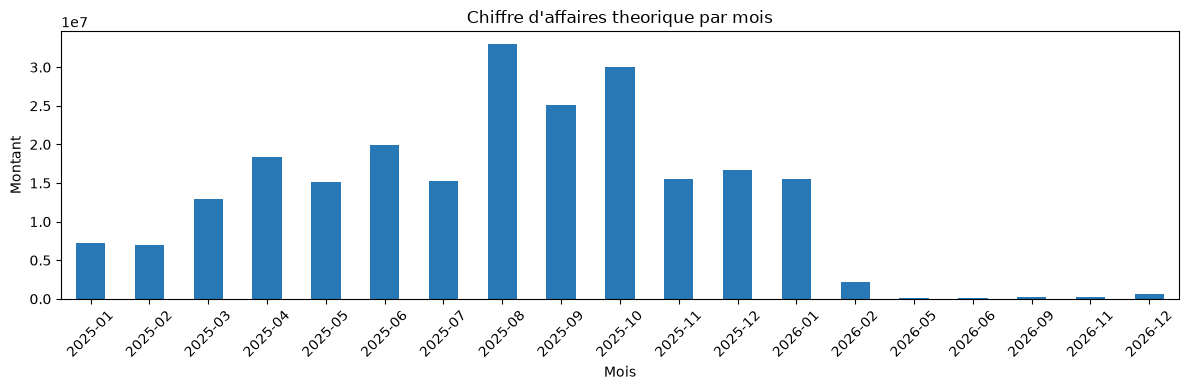

In [34]:
monthly = active.assign(mois=active.date_commande.dt.to_period('M').astype(str)).groupby('mois').chiffre_affaires.sum()
monthly.plot(kind='bar', figsize=(12,4), color='#2878b5', title="Chiffre d'affaires theorique par mois")
plt.ylabel('Montant')
plt.xlabel('Mois')
plt.xticks(rotation=45)
plt.tight_layout()
print('Constat : la serie mensuelle permet de distinguer une tendance commerciale d un effet ponctuel ou d une anomalie de saisie.')

Le modele dimensionnel separe les mesures de vente de leurs axes d'analyse. La table de faits reste a la granularite commande-produit ; les dimensions evitent de repeter les attributs client, produit, date, paiement et avis.

In [35]:
dim_client = consolidee[['id_client','nom','prenom','email','telephone','ville','region','date_inscription']].drop_duplicates('id_client').reset_index(drop=True)
dim_client.insert(0, 'client_key', range(1, len(dim_client)+1))
dim_produit = consolidee[['id_produit','nom_produit','categorie','prix_unitaire_produit','stock_disponible']].drop_duplicates('id_produit').reset_index(drop=True)
dim_produit.insert(0, 'produit_key', range(1, len(dim_produit)+1))
dim_date = pd.DataFrame({'date': pd.date_range(consolidee.date_commande.min().normalize(), consolidee.date_commande.max().normalize(), freq='D')})
dim_date['date_key'] = dim_date.date.dt.strftime('%Y%m%d').astype(int)
dim_date['annee'] = dim_date.date.dt.year
dim_date['mois'] = dim_date.date.dt.month
dim_date['trimestre'] = dim_date.date.dt.quarter
dim_paiement = consolidee[['id_paiement','mode_paiement','statut_paiement']].drop_duplicates('id_paiement').dropna(subset=['id_paiement']).reset_index(drop=True)
dim_paiement.insert(0, 'paiement_key', range(1, len(dim_paiement)+1))
dim_avis = consolidee[['id_avis','note','commentaire','date_avis']].drop_duplicates('id_avis').dropna(subset=['id_avis']).reset_index(drop=True)
dim_avis.insert(0, 'avis_key', range(1, len(dim_avis)+1))
fact_ventes = consolidee.merge(dim_client[['client_key','id_client']], on='id_client', how='left').merge(dim_produit[['produit_key','id_produit']], on='id_produit', how='left')
fact_ventes['date_key'] = fact_ventes.date_commande.dt.strftime('%Y%m%d').astype('Int64')
fact_ventes = fact_ventes[['id_commande','id_produit','client_key','produit_key','date_key','id_paiement','id_avis','quantite','prix_analyse','montant_calcule','chiffre_affaires','paiement_collecte','statut']]
print('Dimensions:', {name: len(df) for name, df in [('client',dim_client),('produit',dim_produit),('date',dim_date),('paiement',dim_paiement),('avis',dim_avis)]})
print('Faits:', fact_ventes.shape, 'lignes ; grain = une ligne produit d une commande')
display(fact_ventes.head())

Dimensions: {'client': 190, 'produit': 59, 'date': 698, 'paiement': 703, 'avis': 397}
Faits: (1201, 13) lignes ; grain = une ligne produit d une commande


,id_commande,id_produit,client_key,produit_key,date_key,id_paiement,id_avis,quantite,prix_analyse,montant_calcule,chiffre_affaires,paiement_collecte,statut
0,CMD00254,PRD050,1,1,20250420,PAY00254,AVI00051,1,75400.0,75400.0,75400.0,0.0,LIVRE
1,CMD00074,PRD036,2,2,20250322,PAY00074,NaN,1,157800.0,157800.0,157800.0,0.0,LIVRE
2,CMD00046,PRD058,3,3,20250803,PAY00046,AVI00215,2,276600.0,553200.0,553200.0,553200.0,LIVRE
3,CMD00033,PRD006,4,4,20250915,PAY00033,NaN,1,482300.0,482300.0,482300.0,0.0,LIVRE
4,CMD00017,PRD004,5,5,20251003,PAY00017,AVI00391,2,560600.0,1121200.0,0.0,0.0,ANNULE


Cette conclusion synthetise les resultats, les limites et les controles a demander a la plateforme avant de prendre des decisions financieres definitives.

In [37]:
print('CONCLUSION')
print('- Les exports permettent de mesurer les commandes, les produits, les clients et la satisfaction apres nettoyage.')
print('- Le chiffre d affaires calcule est theorique : il exclut les commandes annulees, mais les paiements ne se reconcilient pas toujours avec les lignes de commande.')
print('- Les anomalies prioritaires a signaler sont les doublons, les references orphelines, les dates heterogenes, les montants incoherents, les prix catalogue manquants et les notes invalides.')
print('- La serie mensuelle contient des periodes allant jusqu a 2026-12 avec de tres faibles montants ; ces dates doivent etre verifiees dans la source avant toute interpretation de tendance.')
print('- La plateforme doit controler la source des paiements, le referentiel produit et la regle metier des remboursements avant d utiliser ces montants pour la comptabilite.')
print('- Le modele en etoile fournit ensuite des dimensions reutilisables pour interroger l activite par periode, client, ville, categorie, paiement et satisfaction.')

CONCLUSION
- Les exports permettent de mesurer les commandes, les produits, les clients et la satisfaction apres nettoyage.
- Le chiffre d affaires calcule est theorique : il exclut les commandes annulees, mais les paiements ne se reconcilient pas toujours avec les lignes de commande.
- Les anomalies prioritaires a signaler sont les doublons, les references orphelines, les dates heterogenes, les montants incoherents, les prix catalogue manquants et les notes invalides.
- La serie mensuelle contient des periodes allant jusqu a 2026-12 avec de tres faibles montants ; ces dates doivent etre verifiees dans la source avant toute interpretation de tendance.
- La plateforme doit controler la source des paiements, le referentiel produit et la regle metier des remboursements avant d utiliser ces montants pour la comptabilite.
- Le modele en etoile fournit ensuite des dimensions reutilisables pour interroger l activite par periode, client, ville, categorie, paiement et satisfaction.
